In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# LM324 open loop transfer function

# For unity gain bandwidth
# 1 = Aol/|(jw/wc + 1)|
# |jw/wc + 1| = Aol
# 1 + w0^2/wc^2  = Aol^2
# w0 = Aol*wc
# f0 = Aol*fc
# fc = f0/Aol

Aol_dB = 110
Aol = 10**(Aol_dB/20)

fc = 4
f0 = Aol*fc

#f0 = 1e6
#fc = f0/Aol

print(f"f_unity={f0/1e6:.2f}MHz")

def H1(s):
    T = 1/(2*np.pi*fc)
    return Aol/(T*s + 1)

f_unity=1.26MHz


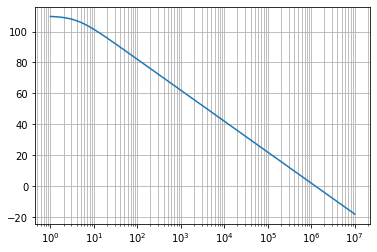

In [3]:
f = np.logspace(0,7,10*100)
w = 2*np.pi*f
s = 1j*w

H1_mag = H1(s)

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.plot(f, 20*np.log10(np.abs(H1_mag)))
ax.set_xscale('log')
ax.grid(True, which='both')

In [4]:
# With capacitive load on the output
# Vo = Aol/(Ts+1) * (V+ - V-)
# V+ = Vi

# We have a RRC network
# Ro --> R --> C
# Ro is the output resistance of the op amp

# V* = Vo * 1/(s(Ro+R)C + 1)
# V- = Vo * (R + 1/sC) / (Ro + R + 1/sC)
# V- = Vo * (sRC+1)/(s(Ro+R)C + 1)

# Vo = Aol/(Ts+1) * (Vi - Vo * (sRC+1)/[s(Ro+R)C+1])

#T1 = RC
#T2 = (Ro+R)C

# Vo = Vi*Aol*/(Ts+1) - Vo * Aol*(T1s+1)/[(T2s+1)(Ts+1)]
# Vo/Vi = Aol/(Ts+1) * [(T2s+1)(Ts+1)]/[(T2s+1)(Ts+1) + Aol*(T1s+1)]
# Vo/Vi = Aol * (T2s+1) / [(T2s+1)(Ts+1) + Aol*(T1s+1)]

# Vo/Vi = Aol * (T2s+1) / [s^2(T2*T) + s(T2+T+Aol*T1) + (1+Aol)]

# For sufficiently large Aol
# Vo/Vi = Aol * (T2s+1) / [s^2(T2*T) + s*Aol*T1 + Aol]
# Vo/Vi = Aol * (T2s+1)/(T2*T) / [s^2 + s*Aol*T1/(T2*T) + Aol/(T2*T)]

# wn^2 = Aol/(T2*T)
# wn^2 = Aol/[(Ro+R)CT]

# wn/Q = Aol*T1/(T2*T)
# wn/Q = Aol*RC/[(Ro+R)C*T]
# wn/Q = Aol*R/[(Ro+R)T]
# Q^2 = Aol/[(Ro+R)CT]   * [(Ro+R)T]^2 / (Aol*R)^2
# Q^2 = 1/Aol * (Ro+R)T * 1/(RC)^2
# Q^2 = T/Aol * (Ro+R) * 1/(RC)^2
# Q = sqrt(...)

Ro = 5
R = 10
C = 4e-6

T = 1/(2*np.pi*fc)
Q = (T/Aol * (Ro+R) / (R*C)**2)**0.5

print(f"Q={Q:.2f}")

Q=34.35


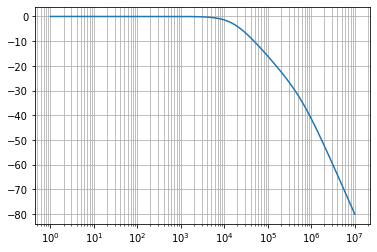

In [5]:
# V-(s)/Vo(s) = H2(s) = (sRC+1)/(s(Ro+R)C + 1)
# V*(s)/Vo(s) = H3(s) = 1/[s(Ro+R)C + 1]

# Vo(s) = H1(s)*(V+(s) - V-(s))
# Vo(s) = H1(s)*(Vi(s) - Vo(s)*H2(s))
# Vo(s)/Vi(s) = H1(s)/[1+H1(s)H2(s)]

# V*(s)/Vi(s) = H3(s)H1(s)/[1+H1(s)H2(s)]

def H1(s, Aol, fc):
    T = 1/(2*np.pi*fc)
    return Aol/(T*s + 1)

def H2(s, Ro, R, C):
    return (s*R*C+1)/(s*(Ro+R)*C + 1)

def H3(s, Ro, R, C):
    return 1/(s*(Ro+R)*C + 1)

def T(s, Aol, fc, Ro, R, C):
    H1_ = H1(s, Aol, fc)
    H2_ = H2(s, Ro, R, C)
    H3_ = H3(s, Ro, R, C)
    return H3_*H1_/(1 + H1_*H2_)

Ro = 10
R = 10
C = 1e-6


f = np.logspace(0,7,10*100)
w = 2*np.pi*f
s = 1j*w

T_mag = T(s, Aol, fc, Ro, R, C)

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.plot(f, 20*np.log10(np.abs(T_mag)))
ax.set_xscale('log')
ax.grid(True, which='both')

Text(0, 0.5, 'Impedance (Ohms)')

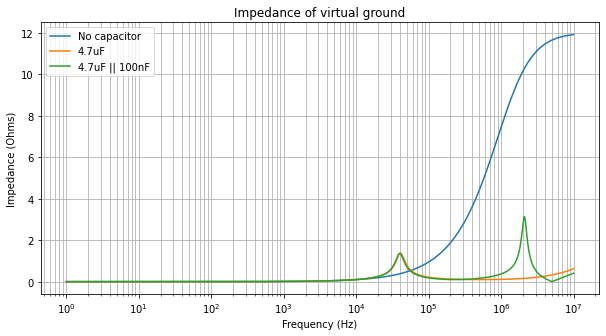

In [21]:
# Consider in reference to a current source entering the load
# Let the impedance of the capacitor be described by C(s)
# (Vg(s)-Vo(s))/(Ro+R) + Vg(s)/C(s) = I(s)
# Vg(s)*[1/(Ro+R) + 1/C(s)] - Vo(s)/(Ro+R) = I(s)

# Goal is to get Vg(s)/I(s) or the impedance of the virtual ground
# Vo(s) = H1(s)*(V+(s) - V-(s))
# V+(s) = 0
# Vo(s) = -H1(s)V-(s)

# Consider output feeding to amplifier
# [Vo(s)-V-(s)]/Ro = [V-(s)-Vg(s)]/R
# Vo(s) - V-(s) = Ro/R * [V-(s) - Vg(s)]
# V-(s) * (Ro/R + 1) = Vo(s) + Ro/R * Vg(s)
# V-(s) = R/(Ro+R) * Vo(s) + Ro/(Ro+R) * Vg(s)

# Vo(s) = -R/(Ro+R) * H1(s)*Vo(s) - Ro/(Ro+R) * H1(s)*Vg(s)

# Let Re = Ro+R

# Vo(s) * (1 + H1(s)*R/Re) = -Ro/Re * H1(s)*Vg(s)
# Vo(s) = -H1(s)*(Ro/Re)/[1 + H1(s)*R/Re] * Vg(s)
# Vo(s) = -H1(s)*Ro/[Re + H1(s)*R] * Vg(s)

# Vg(s)*[1/Re + 1/C(s)] + H1(s)*(Ro/Re)/[Re + H1(s)*R] * Vg(s) = I(s)
# Vg(s)/I(s) = 1 / { [1/Re + 1/C(s)] + H1(s)*(Ro/Re)/[Re + H1(s)*R] }

def parallel(A,B):
    return 1/(1/A + 1/B)

def Cs(s, C, L, R):
    return 1/(s*C) + s*L + R    

def H1(s, Aol, fc):
    T = 1/(2*np.pi*fc)
    return Aol/(T*s + 1)

def Z(s, Aol, fc, Cs, R, Ro):
    Re = R+Ro
    H1_ = H1(s, Aol, fc)
    
    Y = (1/Re + 1/Cs) + H1_*(Ro/Re)/(Re + H1_*R)
    Z = 1/Y
    return Z
    
f = np.logspace(0,7,10*1000)
w = 2*np.pi*f
s = 1j*w

# op amp output resistance
Ro = 12
R = 0
#C = 22e-6
#C = 100e-9


Cs_1 = Cs(s, 10e-6, 10e-9, 0.1)
# parallel electrolytic and ceramic capacitor
Cs_2 = parallel(
    Cs(s, 10e-6, 50e-9, 0.1),
    Cs(s, 100e-9, 10e-9, 0.001))
#Cs_3 = 1/(s*4.7e-6)
#Cs_4 = Cs(s, 4.7e-6, 50e-9, 0.1)

Z0_mag = Z(s, Aol, fc, np.inf, R, Ro)
Z1_mag = Z(s, Aol, fc, Cs_1, R, Ro)
Z2_mag = Z(s, Aol, fc, Cs_2, R, Ro)
Z3_mag = Z(s, Aol, fc, Cs_3, R, Ro)
Z4_mag = Z(s, Aol, fc, Cs_4, R, Ro)

fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(1,1,1)
ax.plot(f, np.abs(Z0_mag))
ax.plot(f, np.abs(Z1_mag))
ax.plot(f, np.abs(Z2_mag))
#ax.plot(f, np.abs(Z3_mag))
#ax.plot(f, np.abs(Z4_mag))
#ax.plot(f, 20*np.log10(np.abs(Z_mag)))
ax.set_xscale('log')
ax.legend(["No capacitor", "4.7uF", "4.7uF || 100nF"])
ax.grid(True, which='both')
ax.set_title("Impedance of virtual ground")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Impedance (Ohms)")

In [ ]:
# Vg(s)/I(s) = 1 / { [1/Re + 1/C(s)] + H1(s)*(Ro/Re)/[Re + H1(s)*R] }
# Re = Ro, R=0
# C(s) = inf
# Z(s) = 1 / {1/Ro + H1(s)/(Ro)}
# Z(s) = Ro / (1 + H1(s))